<a href="https://colab.research.google.com/github/eduardodpms/UnB_Notebooks/blob/main/24.1%20TEMA/Trabalho%201/1o_projeto_tema_01_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Identificação do Aluno/Dupla:

**Nome/Matrícula:** Felipe de Castro Quixabeira / 231026812

**Nome/Matrícula:** Eduardo de Pina Moreira Santos / 231034494


---


## Primeiro Projeto de Tópicos Especiais em Matemática Aplicada (01/2024)

**Contexto do Conjunto de Dados**

Embora muitos estudos tenham sido realizados no passado sobre fatores que afetam a expectativa de vida, considerando variáveis demográficas, composição de renda e taxas de mortalidade, foi descoberto que o efeito da imunização e do índice de desenvolvimento humano não foi levado em consideração. Além disso, algumas das pesquisas anteriores foram feitas considerando a regressão linear múltipla com base em um conjunto de dados de um ano para todos os países. Portanto, isso dá motivação para resolver ambos os fatores declarados anteriormente, formulando um modelo de regressão ainda com base na regressão linear múltipla, considerando dados de um período de 2000 a 2015 para todos os países. Imunizações importantes como hepatite B, poliomielite e difteria também serão consideradas. Em poucas palavras, este estudo se concentrará em fatores de imunização, fatores de mortalidade, fatores econômicos, fatores sociais e outros fatores relacionados à saúde também. Como as observações deste conjunto de dados são baseadas em diferentes países, será mais fácil para um país determinar o fator de previsão que está contribuindo para um menor valor da expectativa de vida. Isso ajudará a sugerir a um país qual área deve receber importância para melhorar eficientemente a expectativa de vida de sua população.

**Conteúdo**

O projeto depende da precisão dos dados. O repositório de dados do Observatório Global da Saúde (GHO) da Organização Mundial da Saúde (OMS) monitora o estado de saúde, bem como muitos outros fatores relacionados para todos os países. Os conjuntos de dados são disponibilizados ao público para fins de análise de dados de saúde. O conjunto de dados relacionado à expectativa de vida, fatores de saúde para 193 países foi coletado do mesmo site do repositório de dados da OMS e seus dados econômicos correspondentes foram coletados do site das Nações Unidas. Entre todas as categorias de fatores relacionados à saúde, apenas os fatores críticos foram escolhidos, os quais são mais representativos. Foi observado que nos últimos 15 anos, houve um enorme desenvolvimento no setor da saúde, resultando na melhoria das taxas de mortalidade humana, especialmente nas nações em desenvolvimento, em comparação aos últimos 30 anos. Portanto, neste projeto, consideramos dados do ano 2000-2015 para 193 países para análise posterior. Os arquivos de dados individuais foram mesclados em um único conjunto de dados. Na inspeção visual inicial, os dados mostraram alguns valores ausentes. Como os conjuntos de dados eram da OMS, não encontramos erros evidentes. Os dados ausentes foram manipulados no software R usando o comando Missmap. O resultado indicou que a maioria dos dados ausentes era para população, hepatite B e PIB. Os dados ausentes eram de países menos conhecidos, como Vanuatu, Tonga, Togo, Cabo Verde etc. Encontrar todos os dados para esses países foi difícil e, portanto, foi decidido que excluíssemos esses países do conjunto de dados do modelo final. O arquivo mesclado final (conjunto de dados final) consiste em 22 colunas e 2938 linhas, o que significava 20 variáveis de previsão. Todas as variáveis de previsão foram então divididas em várias categorias amplas: Fatores relacionados à imunização, Fatores de mortalidade, Fatores econômicos e Fatores sociais.

**O conjunto de dados visa responder às seguintes perguntas-chave:**

* Os vários fatores de previsão que foram escolhidos inicialmente realmente afetam a expectativa de vida?
* Quais são as variáveis de previsão que realmente afetam a expectativa de vida?
* Um país com um valor de expectativa de vida menor (menor que 65 anos) deve aumentar seus gastos com saúde para melhorar sua expectativa de vida média?
* Como as taxas de mortalidade infantil e adulta afetam a expectativa de vida?
* A expectativa de vida tem correlação positiva ou negativa com hábitos alimentares, estilo de vida, exercícios, fumo, consumo de álcool etc.
* Qual é o impacto da escolaridade na expectativa de vida dos humanos?
* A expectativa de vida tem relação positiva ou negativa com o consumo de álcool?
* Os países densamente povoados tendem a ter menor expectativa de vida?
* Qual é o impacto da cobertura de imunização na expectativa de vida?

*Obs.: este conjunto de dados pode ser encontrado no [Kaggle](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who)*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

A príncipio, importa-se o arquivo *.csv* contendo os dados para análise para o *DataFrame* "dados", com o auxílio da biblioteca *Pandas*.

In [ ]:
dados = pd.read_csv(filepath_or_buffer='life_expectancy_data_new.csv')

dados.info()
#print(dados.to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 2938 non-null   object 
 1   Year                    2938 non-null   int64  
 2   Status                  2938 non-null   object 
 3   Life Expectancy         2928 non-null   float64
 4   GDP                     2490 non-null   object 
 5   Population              2286 non-null   object 
 6   ICOR                    2771 non-null   float64
 7   Schooling               2775 non-null   float64
 8   Total Expenditure       2712 non-null   float64
 9   Percentage Expenditure  2938 non-null   object 
 10  Adult Mortality         2928 non-null   float64
 11  Under-Five Deaths       2938 non-null   int64  
 12  Infant Deaths           2938 non-null   int64  
 13  BMI                     2904 non-null   float64
 14  Alcohol                 2744 non-null   

Percebe-se, com o uso do método *info*, uma quantidade considerável de células nulas em diferentes linhas e colunas da tabela original. Para melhor análise dos dados, remove-se todas as linhas com alguma célula vazia do *DataFrame*, com o uso do método *dropna*.

In [ ]:
dados = dados.dropna() #Remove as linhas que contenham alguma célula vazia (NaN).

dados.info()
#print(dados.to_string())

<class 'pandas.core.frame.DataFrame'>
Index: 1649 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 1649 non-null   object 
 1   Year                    1649 non-null   int64  
 2   Status                  1649 non-null   object 
 3   Life Expectancy         1649 non-null   float64
 4   GDP                     1649 non-null   object 
 5   Population              1649 non-null   object 
 6   ICOR                    1649 non-null   float64
 7   Schooling               1649 non-null   float64
 8   Total Expenditure       1649 non-null   float64
 9   Percentage Expenditure  1649 non-null   object 
 10  Adult Mortality         1649 non-null   float64
 11  Under-Five Deaths       1649 non-null   int64  
 12  Infant Deaths           1649 non-null   int64  
 13  BMI                     1649 non-null   float64
 14  Alcohol                 1649 non-null   float

**Observação sobre a planilha de dados**

O índice ICOR (Income Composition of Resources) vai de 0 a 1 e mede, de forma resumida, a qualidade de uso dos recursos em um país.

O arquivo com conjunto de dados fornecidos para o índice ICOR foi corrompido após interação com a ferramenta Google Planilhas, para visualização e organização das colunas (sem alteração dos dados pelo usuário). Assim, parte dos dados se encontrava no intervalo correto, enquanto a grande maioria se encontrava em uma razão de 1000 para 1 com o que seria o seu valor real. Por isso, foi feita a correção abaixo:

In [ ]:
lst = list(dados['ICOR'])
for i in range (len(lst)):
  if lst[i] > 1:
    lst[i] = lst[i]/1000

dados['ICOR'] = lst

#print(dados.to_string())
#dados.to_csv('out.csv')

# **Início**

A fim de analisar a relação de uma série de fatores relativos aos habitantes de 193 países diferentes ao longo de 16 anos com a Expectativa de Vida desses mesmos, importamos o arquivo que será utilizado no trabalho com o auxílio da biblioteca Panda.

Para compararmos a Expectativa de Vida com as variáveis de interesse em gráficos gerados pela biblioteca Seaborn, vamos separá-las em 4 grupos principais:

* Fatores Econômico-Sociais;
* Fatores de Mortalidade;
* Fatores de Saúde;
* Fatores de Imunização.

# **Fatores Econômico-Sociais:**

* **GDP:** PIB per capita, em Dólares;
* **Population:** População estimada do país no ano dado;
* **ICOR (Income Composition of Resources):** Índice de 0 a 1, mede a qualidade do uso dos recursos de um país;
* **Schooling:** Número médio de anos de escolaridade;
* **Total Expenditure:** Porcentagem dos gastos com saúde com relação ao total de gastos públicos;
* **Percentage Expenditure:** Porcentagem dos gastos com saúde com relação ao PIB per capta.




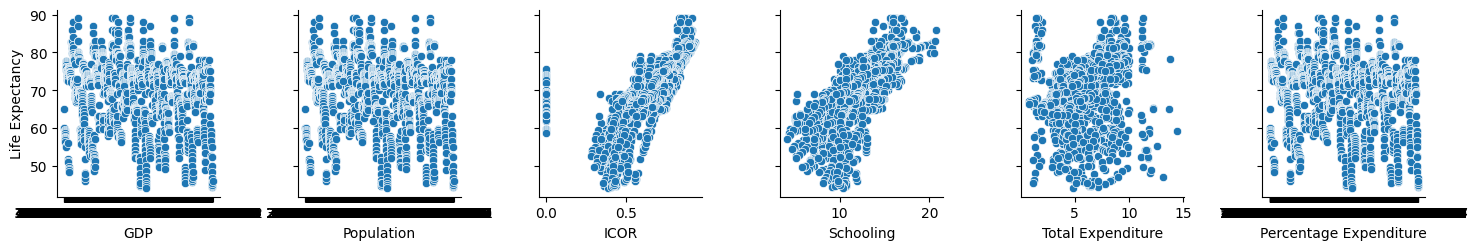

In [ ]:
sns.pairplot(data=dados,
             x_vars=['GDP','Population','ICOR','Schooling','Total Expenditure','Percentage Expenditure'],
             y_vars=['Life Expectancy'])

# **Fatores de Mortalidade:**

* **Adult Mortality:** Número de mortes entre 15 e 60 anos em 1000 indivíduos;
* **Under-Five Deaths:** Número de mortes até 5 anos de vida em 1000 indivíduos;
* **Infant Deaths:** Número de mortes no 1° ano de vida em 1000 indivíduos.

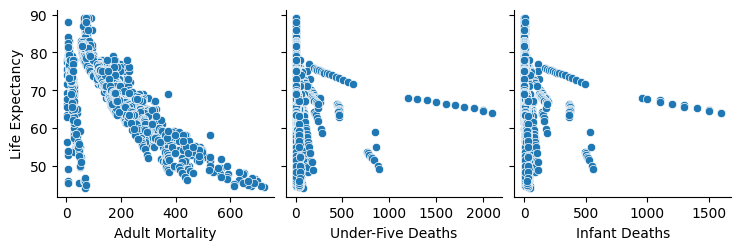

In [ ]:
sns.pairplot(data=dados,
             x_vars=['Adult Mortality','Under-Five Deaths','Infant Deaths'],
             y_vars=['Life Expectancy'])

# **Fatores de Saúde:**

* **BMI:** Índice de Massa Corporal Médio da população;
* **Alcohol:** Consumo de álcool (idade > 15) per capta, em litros de álcool puro;
* **HIV:** Mortes por HIV a cada 1000 bebês de 0-4 anos;
* **Measles:** Número de casos registrados de Sarampo em 1000 habitantes;
* **Thinness (5-9, 10-19):** Porcentagem de jovens com magreza.

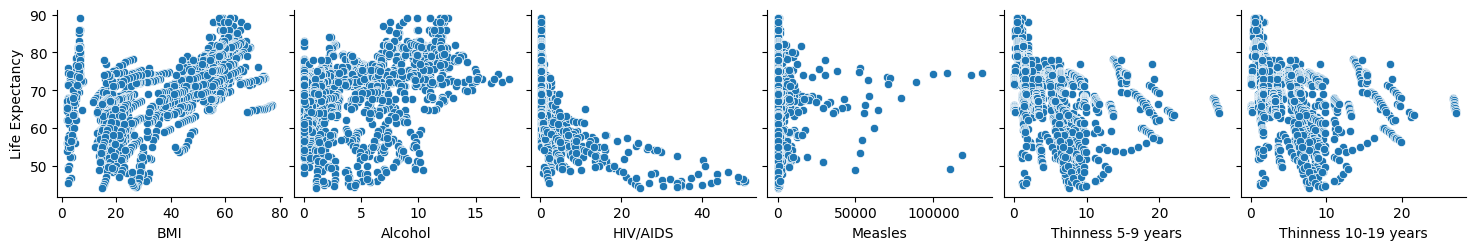

In [ ]:
sns.pairplot(data=dados,
             x_vars=['BMI','Alcohol','HIV/AIDS','Measles','Thinness 5-9 years','Thinness 10-19 years'],
             y_vars=['Life Expectancy'])

# **Fatores de Imunização:**

* **Diphtheria:** Cobertura da imunização contra Difteria em bebês de 1 ano (%);
* **Hepatitis B:** Cobertura da imunização contra Hepatite B em bebês de 1 ano (%);
* **Polio:** Cobertura da imunização contra Poliomielite em bebês de 1 ano (%).

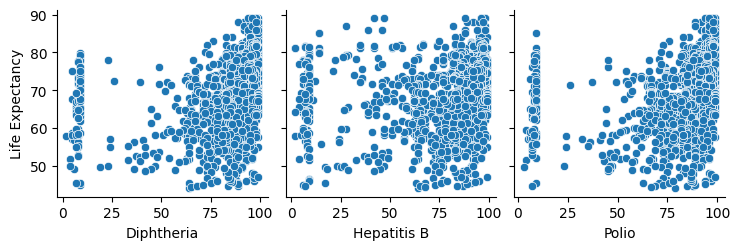

In [ ]:
sns.pairplot(data=dados,
             x_vars=['Diphtheria','Hepatitis B','Polio'],
             y_vars=['Life Expectancy'])

# **Análise**

Após investigação dos gráficos relacionando a expectativa de vida com as outras variáveis em destaque, é perceptível a concentração dos pontos em determinadas regiões do plano. A nossa procura deve se concentrar naquelas que possuem tal concentração em uma região que simbolize uma curva de crescimento definida ou, nesse caso, uma reta.

Nesse sentido, são perceptíveis "retas" de crescimento nas variáveis "ICOR" e "Schooling", e de descrescimento na variável "Mortalidade Adulta". Por isso, vamos direcionar a nossa análise para essas variáveis.

# **Índice ICOR**

O índice Income Composition of Resources, ou ICOR, é um medidor tradicionalmente utilizado nas pesquisas de saúde e expectativa de vida em uma população, uma vez que relaciona o impacto dos investimentos governamentais nesses aspectos.

O medidor varia de 0 a 1 e, quanto maior ele é, melhor é a administração de um determinado país na gestão, distribuição e utilização dos recursos disponíveis para o desenvolvimento do país e, principalmente, de sua população.

Por isso, espera-se, de fato, uma correlação desse índice com a expectativa de vida, uma vez que a correta gestão desses recursos (maior ICOR) significa uma melhor administração financeira voltada para o bem estar da população.

Na plotagem gráfica abaixo, visualiza-se uma relação próxima a linear entre um maior ICOR e uma maior expectativa de vida em uma nação.

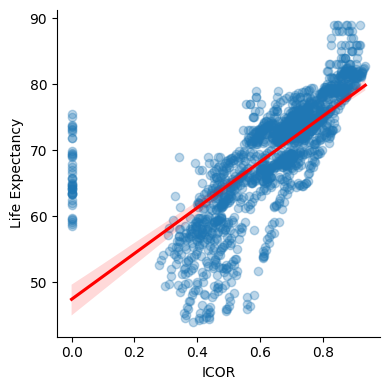

In [ ]:
sns.lmplot(x='ICOR',
           y='Life Expectancy',
           data=dados,
           scatter_kws={'alpha':0.3},
           line_kws={'color': 'red'},
           height=4)

Neste caso, observa-se uma quantidade significante de dados nos quais o índice ICOR é igual a 0. Naturalmente, tratam-se de dados incoerentes com a realidade.

In [ ]:
count = 0
lst = list(dados['ICOR'])
for i in range (len(lst)):
  if lst[i] == 0:
    count = count + 1

print(f'A quantidade de dados nulos relativos ao índice ICOR é igual a {count}.')

A quantidade de dados nulos relativos ao índice ICOR é igual a 48.


Tais informações, entretanto, geram uma inclinação visivelmente incorreta da reta originada pela regressão linear. Por isso, faremos um tratamento dos dados nulos utilizando médias.

O processo consistirá no cálculo da média dos valores não nulos do ICOR naquele país e na substituição do valor nulo por essa média.

Perceba que, para um país com múltiplos valores nulos de ICOR, a média será atualizada cada vez que um valor nulo for substituído.

In [ ]:
names = list(dados['Country'])
names_in = list(names)
names_in.reverse()
icor = list(dados['ICOR'])
first = True

for i in range (len(icor)):
  if icor[i] == 0:

    if first: #Deixa o primeiro elemento nulo inalterado, para ajustar a escala do gráfico.
      first = False
      continue

    country = names[i]
    first_i = names.index(country) #Índice do primeiro elemento do país em foco.
    last_i = len(names_in) - names_in.index(country) - 1 #Índice do último elemento do país em foco.

    n, mean = 0, 0
    for j in range (last_i - first_i + 1): #Loop para o cálculo da média.
      if icor[first_i + j] != 0:
        mean = mean + icor[first_i + j]
        n = n + 1

    icor[i] = mean/n

dados['ICOR'] = icor

#print(dados.to_string())

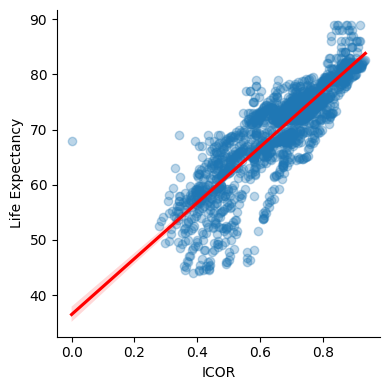

In [ ]:
sns.lmplot(x='ICOR',
           y='Life Expectancy',
           data=dados,
           scatter_kws={'alpha':0.3},
           line_kws={'color': 'red'},
           height=4)

Após o tratamento dos dados, temos uma otimização dos mesmos para uma regrassão linear com uma qualidade visivelmente melhor.

# **Escolaridade**

O índice Escolaridade (do inglês Schooling) é referente ao tempo médio de permanência das pessoas em uma unidade de educação do país. Com isso, ele é uma métrica não só para o investimento das instituições públicas na educação, como também para a visão de uma dada população sobre o ensino.

Sobre a relação desse índice com a Expectativa de Vida, cabe mencionar que a educação é a porta de entrada da população para uma série de conhecimentos que podem prolongar o tempo de vida de modo geral. Cabe mencionar o estudo sobre vacinas, métodos contraceptivos, conhecimentos gerais para o mercado de trabalho, nutrição, fisiologia, entre incontáveis outros.

Como forma de visualizar esse fenômeno com dados reais, foi feita a análise gráfica com a regressão linear de uma reta sobre o gráfico contendo os dados *Schooling* X *Life Expectancy*, com o auxílio da biblioteca SeaBorn, na qual é perceptível uma relação direta e visível entre as variáveis em estudo.

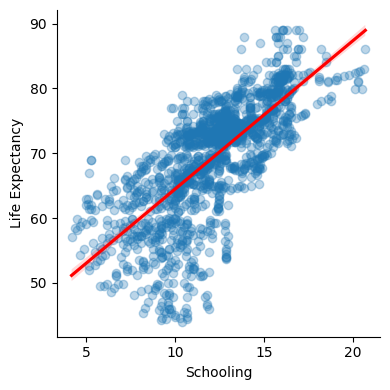

In [ ]:
sns.lmplot(x='Schooling',
           y='Life Expectancy',
           data=dados,
           scatter_kws={'alpha':0.3},
           line_kws={'color': 'red'},
           height=4)

# **Mortalidade Adulta**

Por último, cabe analisar a relação Mortalidade Adulta X Expectativa de Vida. O índice Mortalidade Adulta está relacionado a uma série de outros fatores, os quais não estão necessariamente presentes no conjunto de dados utilizado. Entretanto, são, em sua maioria, consequências de medidas administrativas ou de hábitos culturais.

Como é perceptível na regressão linear e na maneira como os pontos se agrupam no gráfico montado, essa trata-se de uma relação decrescente. Esse fato ocorre pois, ao contrário dos fatores estudados anteriormente, a mortalidade de adultos é uma métrica cujo crescimento prejudica a expectativa de vida. Isso significa que, um aumento do percentual de mortes entre 15 e 60 anos acarreta, por consequência, em um menor tempo de vida no geral.

Com esse fato, verifica-se a plotagem de uma reta com inclinação negativa na aplicação da regressão linear mas que, ainda sim, apresenta uma relação linear visível entre as variáveis em análise.

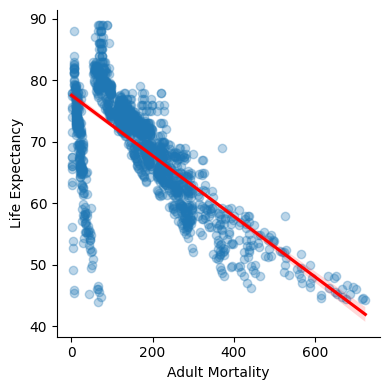

In [ ]:
sns.lmplot(x='Adult Mortality',
           y='Life Expectancy',
           data=dados,
           scatter_kws={'alpha':0.3},
           line_kws={'color': 'red'},
           height=4)

Nesse caso, assim como no gráfico *ICOR* X *Life Expectancy*, é perceptível uma grande quantidade de outliers, resultado de erros na coleta ou fornecimento de dados, os quais podem afetar a nossa regressão linear.

Por isso, vamos tratar os dados com a informação de mortalidade adulta < 50, para que se ajustem à média geral dos dados daquele país, de forma semelhante ao processo feito na análise do índice ICOR.

In [ ]:
names = list(dados['Country'])
names_in = list(names)
names_in.reverse()
adult_m = list(dados['Adult Mortality'])

for i in range (len(adult_m)):
  if adult_m[i] < 50:
    country = names[i]
    first_i = names.index(country) #Índice do primeiro elemento do país em foco.
    last_i = len(names_in) - names_in.index(country) - 1 #Índice do último elemento do país em foco.

    n, mean = 0, 0
    for j in range (last_i - first_i + 1): #Função para o cálculo da média.
      mean = mean + adult_m[first_i + j]
      n = n + 1

    adult_m[i] = mean/n

dados['Adult Mortality'] = adult_m

#print(dados.to_string())

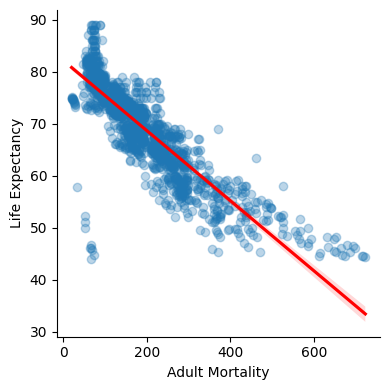

In [ ]:
sns.lmplot(x='Adult Mortality',
           y='Life Expectancy',
           data=dados,
           scatter_kws={'alpha':0.3},
           line_kws={'color': 'red'},
           height=4)

# **Perguntas-Chave**

**1. Os vários fatores de previsão que foram escolhidos inicialmente realmente afetam a expectativa de vida?**

  Após análise dos gráficos que relacionam os fatores de previsão escolhidos com a Expectativa de Vida, é possível concluir que a maioria deles não afeta diretamente a nossa variável de interesse. Dentre eles, apenas o índice ICOR (Income Composition of Resources), a Escolaridade e a Mortalidade Adulta realmente possuem relação direta com a expectativa de vida.

---

**2. Quais são as variáveis de previsão que realmente afetam a expectativa de vida?**

Após análise dos dados fornecidos e de seus respectivos gráficos, conclui-se que a Expectativa de Vida em um país é mais afetada por:

* **ICOR (Income Composition of Resources):** Esse índice encontra-se em uma escala de 0 a 1 e representa diretamente o quão bem um país gere os seus recursos financeiros, naturais e sociais. Nesse sentido, ele está diretamente relacionado com o investimento em áreas estratégicas que promovem o aumento da expectativa de vida, como a escolaridade. Assim, possui uma relação direta com a Expectativa de Vida, conforme observado na regressão linear realizada.

* **Escolaridade (Schooling):** A escolaridade, de forma resumida, corresponde a uma métrica para o tempo de permanência de um habitante em uma unidade educativa do país. Assim, considerando o impacto do ensino em diversas características que promovem a expectativa de vida de um indivíduo, evidencia-se a relação direta existente entre ambas as variáveis, como constatado no gráfico contendo a regressão linear.

* **Mortalidade Adulta (Adult Mortality):** A mortalidade adulta trata-se de uma métrica para a quantidade média de mortes entre 15 e 60 anos entre 1000 habitantes. Assim, ela está diretamente ligada à frequência de mortes em uma população que, por sua vez, está diretamente ligada à expectativa de vida. Esse índice, ao contrário dos outros 2, afeta negativamente a nossa variável de interesse, por isso gerou uma regressão linear com inclinação negativa. Entretanto, ainda assim, possui relação direta com ela.

---

**3. Um país com um valor de expectativa de vida menor (menor que 65 anos) deve aumentar seus gastos com saúde para melhorar sua expectativa de vida média?**

Após análise dos resultados das regressões lineares, é possível concluir que países com expectativas de vida menores a 60 anos devem aumentar seus gastos com saúde se buscarem aumentar essa expectativa. Isso ocorre pois o índice ICOR, que mede a qualidade da gestão dos recursos, é um dos principais responsáveis pelo aumento da variável desejada. Assim, ao promover o investimento em áreas estratégicas em um determinado país, entre as quais possivelmente se encontra a área da saúde, haverá um aumento do índice ICOR e, consequentemente, um aumento da expectativa de vida.

---

**4. Como as taxas de mortalidade infantil e adulta afetam a expectativa de vida?**

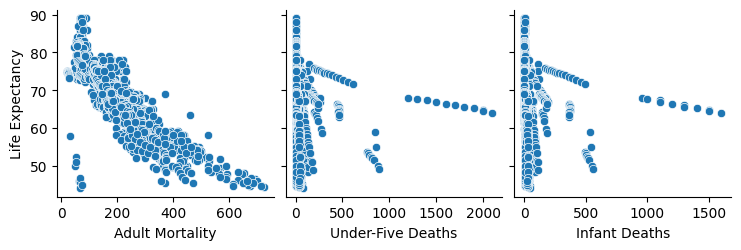

In [ ]:
sns.pairplot(data=dados,
             x_vars=['Adult Mortality','Under-Five Deaths','Infant Deaths'],
             y_vars=['Life Expectancy'])

As taxas de mortalidade juvenil e infantil, conforme visto nos gráficos acima, não parecem possuir relação direta com a expectativa de vida de um país. Isso ocorre pois tais métricas se concentram na análise de um tempo de vida curto quando comparado com o tempo de vida de um adulto médio. Por outro lado, a mortalidade adulta já leva em consideração todo o tempo de vida de um indivído e, conforme pôde ser concluido com a análise da regressão linear, possui relação direta com o decrescimento da expectativa de vida.

---

**5. A expectativa de vida tem correlação positiva ou negativa com hábitos alimentares, estilo de vida, exercícios, fumo, consumo de álcool, etc.?**

Após análise da relação de variáveis como IMC e consumo de álcool com a expectativa de vida, é possível concluir que aquelas possuem uma relação positiva mínima com esta. Isso significa que, após análise do gráfico, é percepetível um certo direcionamento dos pontos ao entorno de uma reta crescente. Entretanto, há uma baixa concentração de pontos, a qual não permite a aplicação de uma regressão linear com precisão. Por isso, tal conclusão se restringe a um bom senso, e não pode ser atestada com certeza.

---

**6. Qual é o impacto da escolaridade na expectativa de vida dos humanos?**

Conforme observado na regressão linear, o tempo médio de permanência dos habitantes nas unidades de educação do país possui grande impacto positivo no aumento da expectativa de vida do mesmo. Isso ocorre pois o conhecimento, representado pela escolaridade, fornece ao indivíduo uma série de capacidades que extendem o seu tempo de vida.

---

**7. A expectativa de vida tem relação positiva ou negativa com o consumo de álcool?**

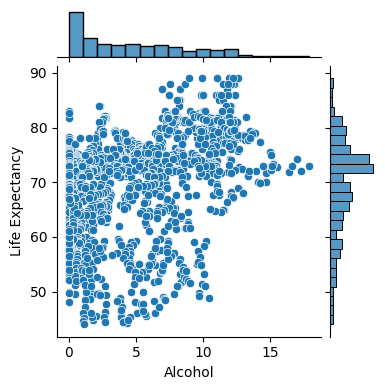

In [ ]:
sns.jointplot(x='Alcohol', y='Life Expectancy', data=dados, height=4)

A princípio, é natural pensar que o consumo de álcool possui relação negativa com o aumento da expectativa de vida em uma população, uma vez que prejudica a saúde do indivíduo. Entretanto, conforme análise do gráfico que relaciona as duas variáveis, é perceptível que não há essa relação direta entre elas. Ou seja, a princípio, conclui-se que o consumo de álcool per capta não está diretamente relacionado com uma menor expectativa de vida

---

**8. Os países densamente povoados tendem a ter menor expectativa de vida?**

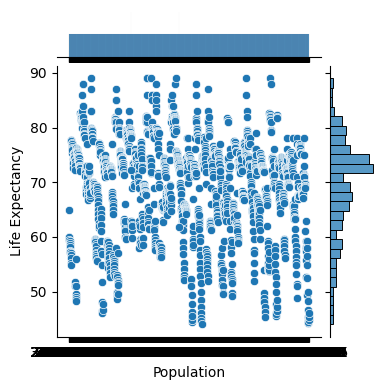

In [ ]:
sns.jointplot(x='Population', y='Life Expectancy', data=dados, height=4)

Conforme análise dos dados fornecidos e do gráfico gerado por eles, é perceptível que não exista qualquer conexão entre a densidade populacional e a expectativa de vida, uma vez que os dados estão agrupados de maneira que não corresponda a nenhuma relação conhecida.

---

**9. Qual é o impacto da cobertura de imunização na expectativa de vida?**

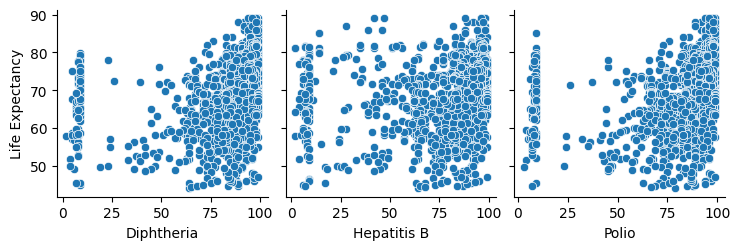

In [ ]:
sns.pairplot(data=dados,
             x_vars=['Diphtheria','Hepatitis B','Polio'],
             y_vars=['Life Expectancy'])

A cobertura da imunização contra Difteria, Hepatite B e Poliomielite, apesar de muito incentivada na grande maioria dos países, não aparenta possuir conexão visível com uma maior expectativa de vida. A análise dos gráficos nos permite concluir que os dados estão concentrados na parte direita do gráfico, tanto em cima quanto em baixo. Ou seja, a expectativa de vida não está diretamente conectada com a cobertura da imunização dessas enfermidades.